In [2]:
# Imports, reproducibility seed, working/figure directories (works on both Kaggle and Colab), and hardware check
import os, glob, time, random, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim_fn
warnings.filterwarnings("ignore")

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)
set_seed()

WORK_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else ("/content" if os.path.isdir("/content") else os.getcwd())
INPUT_DIR = "/kaggle/input" if os.path.isdir("/kaggle/input") else WORK_DIR
FIG_DIR = f"{WORK_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
def save_fig(name):
    plt.savefig(f"{FIG_DIR}/{name}.jpg", dpi=200, bbox_inches="tight")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Working directory:", WORK_DIR)

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Working directory: /kaggle/working


In [3]:
# Load MNIST (Keras download, with a local mnist.npz fallback), take the laboratory subset and normalise to [0, 1]
N_TRAIN, N_VAL, N_TEST = 10000, 2000, 2000

def load_mnist():
    try:
        return keras.datasets.mnist.load_data()
    except Exception as e:
        print("Keras download failed:", e)
        hits = glob.glob(f"{INPUT_DIR}/**/mnist.npz", recursive=True)
        assert hits, "No internet and no mnist.npz found. Attach an MNIST dataset via 'Add Input'."
        with np.load(hits[0]) as f:
            return (f["x_train"], f["y_train"]), (f["x_test"], f["y_test"])

(x_tr_all, y_tr_all), (x_te_all, y_te_all) = load_mnist()
x_train = (x_tr_all[:N_TRAIN] / 255.0).astype("float32")[..., None]
y_train = y_tr_all[:N_TRAIN]
x_val = (x_tr_all[N_TRAIN:N_TRAIN + N_VAL] / 255.0).astype("float32")[..., None]
y_val = y_tr_all[N_TRAIN:N_TRAIN + N_VAL]
x_test = (x_te_all[:N_TEST] / 255.0).astype("float32")[..., None]
y_test = y_te_all[:N_TEST]

xf_train, xf_val, xf_test = [a.reshape(len(a), 784) for a in (x_train, x_val, x_test)]

print("Conv-format tensors (N, 28, 28, 1):")
print(f"Training   : {x_train.shape}")
print(f"Validation : {x_val.shape}")
print(f"Testing    : {x_test.shape}")
print(f"Flattened (N, 784): train {xf_train.shape}, val {xf_val.shape}, test {xf_test.shape}")
print(f"Pixel range: [{x_train.min():.1f}, {x_train.max():.1f}] | dtype {x_train.dtype}")
print("Test-set digit counts:", dict(zip(*np.unique(y_test, return_counts=True))))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Conv-format tensors (N, 28, 28, 1):
Training   : (10000, 28, 28, 1)
Validation : (2000, 28, 28, 1)
Testing    : (2000, 28, 28, 1)
Flattened (N, 784): train (10000, 784), val (2000, 784), test (2000, 784)
Pixel range: [0.0, 1.0] | dtype float32
Test-set digit counts: {np.uint8(0): np.int64(175), np.uint8(1): np.int64(234), np.uint8(2): np.int64(219), np.uint8(3): np.int64(207), np.uint8(4): np.int64(217), np.uint8(5): np.int64(179), np.uint8(6): np.int64(178), np.uint8(7): np.int64(205), np.uint8(8): np.int64(192), np.uint8(9): np.int64(194)}


In [4]:
# Shared evaluation helpers: MSE / MAE / mean SSIM, trainable-parameter count, per-image error, and an image-grid plotter
def as_images(a):
    return np.asarray(a).reshape(len(a), 28, 28)

def image_metrics(x, xhat):
    x, xhat = as_images(x), as_images(xhat)
    mse = float(np.mean((x - xhat) ** 2))
    mae = float(np.mean(np.abs(x - xhat)))
    s = float(np.mean([ssim_fn(a, b, data_range=1.0) for a, b in zip(x, xhat)]))
    return {"MSE": mse, "MAE": mae, "SSIM": s}

def per_image_mse(x, xhat):
    x, xhat = as_images(x), as_images(xhat)
    return ((x - xhat) ** 2).mean(axis=(1, 2))

def n_trainable(m):
    return int(sum(np.prod(w.shape) for w in m.trainable_weights))

def grid_plot(rows, row_labels, title, fname, n=10, cmaps=None):
    cmaps = cmaps or ["gray"] * len(rows)
    fig, axes = plt.subplots(len(rows), n, figsize=(1.25 * n, 1.35 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (data, label, cmap) in enumerate(zip(rows, row_labels, cmaps)):
        imgs = as_images(data)
        for c in range(n):
            axes[r, c].imshow(imgs[c], cmap=cmap, vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_ylabel(label)
        axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    fig.suptitle(title)
    plt.tight_layout(); save_fig(fname); plt.show()

results = {}

In [5]:
# Fully connected autoencoder 784-128-32-(latent)-32-128-784 with ReLU hidden layers and a sigmoid output
EPOCHS, BATCH, LR = 20, 128, 1e-3

def build_fc_ae(latent=16):
    set_seed()
    inp = keras.Input((784,))
    e = layers.Dense(128, activation="relu")(inp)
    e = layers.Dense(32, activation="relu")(e)
    z = layers.Dense(latent, activation="relu", name="latent")(e)
    d = layers.Dense(32, activation="relu")(z)
    d = layers.Dense(128, activation="relu")(d)
    out = layers.Dense(784, activation="sigmoid")(d)
    m = keras.Model(inp, out, name=f"fc_ae_latent{latent}")
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="binary_crossentropy")
    return m

fc_ae = build_fc_ae(16)
fc_ae.summary()
print("Trainable parameters:", n_trainable(fc_ae))

I0000 00:00:1790240381.944432      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790240381.947846      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "fc_ae_latent16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 211040


In [6]:
# Train the fully connected autoencoder (input = target = the image itself; labels are never used)
t0 = time.time()
fc_hist = fc_ae.fit(xf_train, xf_train, validation_data=(xf_val, xf_val),
                    epochs=EPOCHS, batch_size=BATCH, verbose=2).history
fc_time = time.time() - t0
fc_recon = fc_ae.predict(xf_test, verbose=0)
results["FC Autoencoder"] = {**image_metrics(xf_test, fc_recon),
                             "Parameters": n_trainable(fc_ae), "Time (s)": fc_time}
print("\nFC autoencoder test metrics:", {k: round(v, 5) for k, v in results["FC Autoencoder"].items()})

Epoch 1/20


I0000 00:00:1790240388.320141     130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/79 - 7s - 83ms/step - loss: 0.3442 - val_loss: 0.2449
Epoch 2/20
79/79 - 0s - 5ms/step - loss: 0.2255 - val_loss: 0.2023
Epoch 3/20
79/79 - 0s - 5ms/step - loss: 0.1899 - val_loss: 0.1758
Epoch 4/20
79/79 - 0s - 5ms/step - loss: 0.1715 - val_loss: 0.1616
Epoch 5/20
79/79 - 0s - 5ms/step - loss: 0.1593 - val_loss: 0.1519
Epoch 6/20
79/79 - 0s - 5ms/step - loss: 0.1512 - val_loss: 0.1457
Epoch 7/20
79/79 - 0s - 5ms/step - loss: 0.1454 - val_loss: 0.1405
Epoch 8/20
79/79 - 0s - 5ms/step - loss: 0.1413 - val_loss: 0.1370
Epoch 9/20
79/79 - 0s - 5ms/step - loss: 0.1381 - val_loss: 0.1346
Epoch 10/20
79/79 - 0s - 5ms/step - loss: 0.1357 - val_loss: 0.1327
Epoch 11/20
79/79 - 0s - 5ms/step - loss: 0.1336 - val_loss: 0.1313
Epoch 12/20
79/79 - 0s - 5ms/step - loss: 0.1315 - val_loss: 0.1295
Epoch 13/20
79/79 - 0s - 5ms/step - loss: 0.1294 - val_loss: 0.1268
Epoch 14/20
79/79 - 0s - 5ms/step - loss: 0.1271 - val_loss: 0.1246
Epoch 15/20
79/79 - 0s - 5ms/step - loss: 0.1254 - val_loss: 0.1234

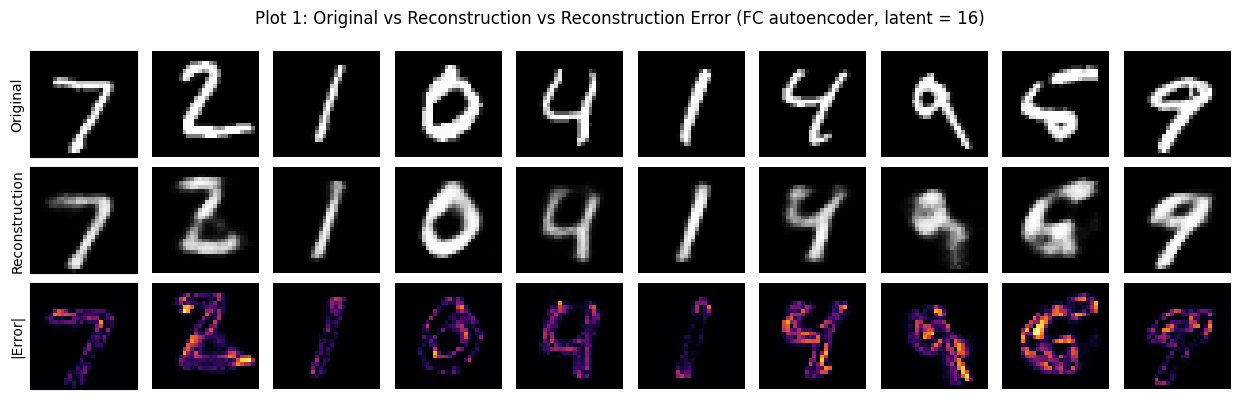

Per-image MSE: mean 0.02100 | min 0.00142 | max 0.07086
Easiest digits (lowest error): [1, 1, 1, 1, 1]
Hardest digits (highest error): [8, 8, 3, 2, 8]


In [7]:
# Plot 1: original vs reconstruction vs absolute reconstruction error for 10 test images
grid_plot([xf_test, fc_recon, np.abs(as_images(xf_test) - as_images(fc_recon))],
          ["Original", "Reconstruction", "|Error|"],
          "Plot 1: Original vs Reconstruction vs Reconstruction Error (FC autoencoder, latent = 16)",
          "plot1_fc_reconstruction", n=10, cmaps=["gray", "gray", "inferno"])
err = per_image_mse(xf_test, fc_recon)
print(f"Per-image MSE: mean {err.mean():.5f} | min {err.min():.5f} | max {err.max():.5f}")
print("Easiest digits (lowest error):", y_test[np.argsort(err)[:5]].tolist())
print("Hardest digits (highest error):", y_test[np.argsort(err)[-5:]].tolist())

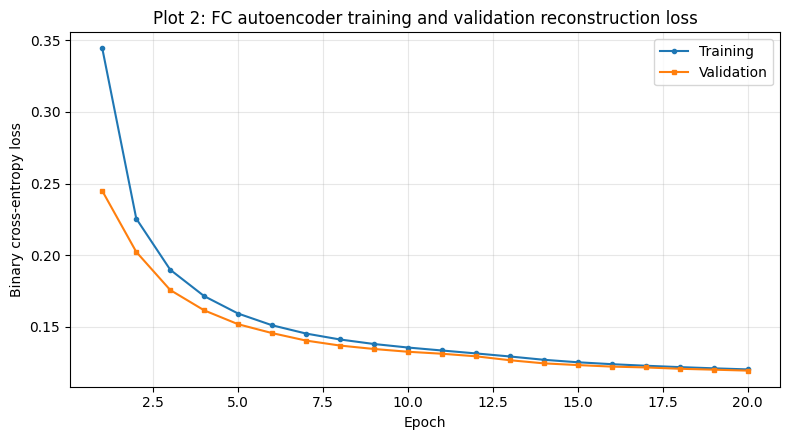

Final train loss 0.1204 | final val loss 0.1196 | gap -0.0008
Min val loss 0.1196 @ epoch 20


In [8]:
# Plot 2: training and validation reconstruction loss for the basic autoencoder
ep = np.arange(1, len(fc_hist["loss"]) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(ep, fc_hist["loss"], "o-", ms=3, label="Training")
plt.plot(ep, fc_hist["val_loss"], "s-", ms=3, label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Binary cross-entropy loss")
plt.title("Plot 2: FC autoencoder training and validation reconstruction loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); save_fig("plot2_fc_loss_curves"); plt.show()
print(f"Final train loss {fc_hist['loss'][-1]:.4f} | final val loss {fc_hist['val_loss'][-1]:.4f} | "
      f"gap {fc_hist['val_loss'][-1] - fc_hist['loss'][-1]:+.4f}")
print(f"Min val loss {min(fc_hist['val_loss']):.4f} @ epoch {int(np.argmin(fc_hist['val_loss'])) + 1}")

In [9]:
# Reconstruction metrics of the basic autoencoder on the untouched test set
print(pd.DataFrame({"Value": {"Test MSE": results["FC Autoencoder"]["MSE"],
                              "Test MAE": results["FC Autoencoder"]["MAE"],
                              "Mean SSIM": results["FC Autoencoder"]["SSIM"]}}).round(5))

             Value
Test MSE   0.02100
Test MAE   0.05547
Mean SSIM  0.75181


In [10]:
# Convolutional autoencoder: Conv/MaxPool encoder and UpSampling/Conv decoder, spatial structure preserved throughout
def build_cae(transpose_decoder=False):
    set_seed()
    inp = keras.Input((28, 28, 1))
    e = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    e = layers.MaxPooling2D(2, padding="same")(e)
    e = layers.Conv2D(64, 3, activation="relu", padding="same")(e)
    e = layers.MaxPooling2D(2, padding="same")(e)
    b = layers.Conv2D(64, 3, activation="relu", padding="same", name="bottleneck")(e)
    if transpose_decoder:
        d = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(b)
        d = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(d)
    else:
        d = layers.UpSampling2D(2)(b)
        d = layers.Conv2D(32, 3, activation="relu", padding="same")(d)
        d = layers.UpSampling2D(2)(d)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(d)
    m = keras.Model(inp, out, name="cae_transpose" if transpose_decoder else "cae")
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="binary_crossentropy")
    return m

cae = build_cae()
cae.summary()
print("Bottleneck feature map:", cae.get_layer("bottleneck").output.shape,
      "->", int(np.prod(cae.get_layer("bottleneck").output.shape[1:])), "latent values per image")

Model: "cae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Bottleneck feature map: (None, 7, 7, 64) -> 3136 latent values per image


In [11]:
# Train the convolutional autoencoder on the same images, same optimizer, same epoch budget as the FC model
t0 = time.time()
cae_hist = cae.fit(x_train, x_train, validation_data=(x_val, x_val),
                   epochs=EPOCHS, batch_size=BATCH, verbose=2).history
cae_time = time.time() - t0
cae_recon = cae.predict(x_test, verbose=0)
results["Convolutional AE"] = {**image_metrics(x_test, cae_recon),
                               "Parameters": n_trainable(cae), "Time (s)": cae_time}
print("\nConvolutional autoencoder test metrics:", {k: round(v, 5) for k, v in results["Convolutional AE"].items()})

Epoch 1/20
79/79 - 10s - 128ms/step - loss: 0.2102 - val_loss: 0.0955
Epoch 2/20
79/79 - 1s - 8ms/step - loss: 0.0890 - val_loss: 0.0815
Epoch 3/20
79/79 - 1s - 8ms/step - loss: 0.0807 - val_loss: 0.0766
Epoch 4/20
79/79 - 1s - 9ms/step - loss: 0.0771 - val_loss: 0.0740
Epoch 5/20
79/79 - 1s - 9ms/step - loss: 0.0749 - val_loss: 0.0725
Epoch 6/20
79/79 - 1s - 8ms/step - loss: 0.0735 - val_loss: 0.0713
Epoch 7/20
79/79 - 1s - 8ms/step - loss: 0.0725 - val_loss: 0.0707
Epoch 8/20
79/79 - 1s - 8ms/step - loss: 0.0717 - val_loss: 0.0700
Epoch 9/20
79/79 - 1s - 8ms/step - loss: 0.0711 - val_loss: 0.0695
Epoch 10/20
79/79 - 1s - 9ms/step - loss: 0.0706 - val_loss: 0.0690
Epoch 11/20
79/79 - 1s - 8ms/step - loss: 0.0702 - val_loss: 0.0686
Epoch 12/20
79/79 - 1s - 9ms/step - loss: 0.0698 - val_loss: 0.0683
Epoch 13/20
79/79 - 1s - 9ms/step - loss: 0.0694 - val_loss: 0.0679
Epoch 14/20
79/79 - 1s - 9ms/step - loss: 0.0691 - val_loss: 0.0678
Epoch 15/20
79/79 - 1s - 9ms/step - loss: 0.0688 - val

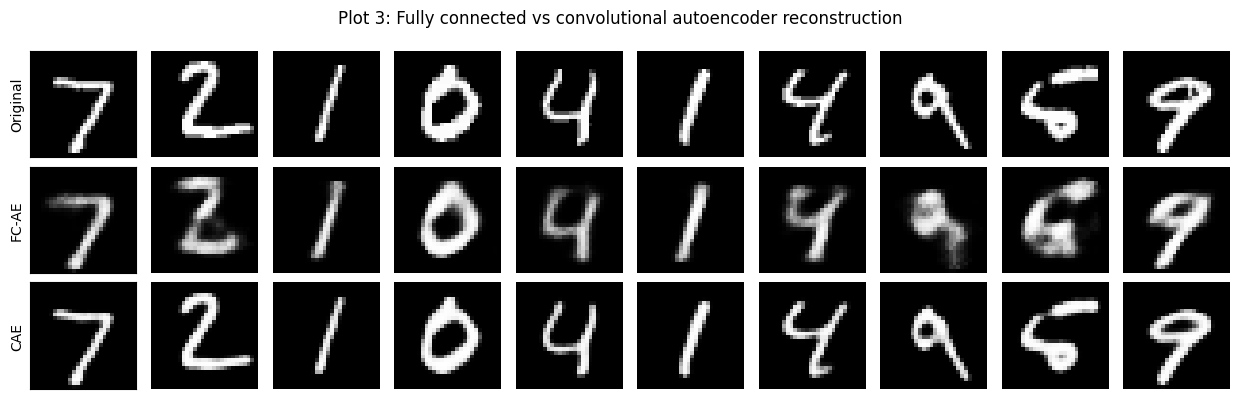

                      MSE      MAE     SSIM  Parameters  Time (s)
FC Autoencoder    0.02100  0.05547  0.75181    211040.0  14.05259
Convolutional AE  0.00241  0.01464  0.97404     74497.0  23.13469

SSIM improvement from convolution: +29.6%
MSE reduction from convolution   : +88.5%


In [12]:
# Plot 3: original vs FC-AE reconstruction vs CAE reconstruction, plus the head-to-head comparison table
grid_plot([x_test, fc_recon, cae_recon], ["Original", "FC-AE", "CAE"],
          "Plot 3: Fully connected vs convolutional autoencoder reconstruction",
          "plot3_fc_vs_cae", n=10)
comp = pd.DataFrame({k: results[k] for k in ["FC Autoencoder", "Convolutional AE"]}).T
print(comp.round(5))
print(f"\nSSIM improvement from convolution: {100*(results['Convolutional AE']['SSIM'] / results['FC Autoencoder']['SSIM'] - 1):+.1f}%")
print(f"MSE reduction from convolution   : {100*(1 - results['Convolutional AE']['MSE'] / results['FC Autoencoder']['MSE']):+.1f}%")

In [13]:
# Noise generators (Gaussian and salt-and-pepper) and the corrupted copies used to train the denoising autoencoder
GAUSS_LEVELS = [0.1, 0.2, 0.3]
SP_LEVELS = [0.05, 0.10, 0.20]
TRAIN_SIGMA = 0.2

def add_gaussian(x, sigma, seed=SEED):
    rng = np.random.RandomState(seed)
    return np.clip(x + rng.normal(0.0, sigma, x.shape), 0.0, 1.0).astype("float32")

def add_salt_pepper(x, p, seed=SEED):
    rng = np.random.RandomState(seed)
    out = x.copy()
    m = rng.random_sample(x.shape)
    out[m < p / 2] = 0.0
    out[(m >= p / 2) & (m < p)] = 1.0
    return out.astype("float32")

xn_train = add_gaussian(x_train, TRAIN_SIGMA, seed=1)
xn_val = add_gaussian(x_val, TRAIN_SIGMA, seed=2)
xn_test = {s: add_gaussian(x_test, s, seed=3) for s in GAUSS_LEVELS}
xsp_test = {p: add_salt_pepper(x_test, p, seed=4) for p in SP_LEVELS}
print(f"Denoising training pairs: noisy input (Gaussian sigma={TRAIN_SIGMA}) -> clean target")
print("Noisy test sets prepared for Gaussian", GAUSS_LEVELS, "and salt-and-pepper", SP_LEVELS)

Denoising training pairs: noisy input (Gaussian sigma=0.2) -> clean target
Noisy test sets prepared for Gaussian [0.1, 0.2, 0.3] and salt-and-pepper [0.05, 0.1, 0.2]


In [14]:
# Train the denoising convolutional autoencoder: corrupted input, clean target, identical architecture to the CAE
dae = build_cae()
t0 = time.time()
dae_hist = dae.fit(xn_train, x_train, validation_data=(xn_val, x_val),
                   epochs=EPOCHS, batch_size=BATCH, verbose=2).history
dae_time = time.time() - t0
dae_recon = dae.predict(xn_test[TRAIN_SIGMA], verbose=0)
results["Denoising CAE"] = {**image_metrics(x_test, dae_recon),
                            "Parameters": n_trainable(dae), "Time (s)": dae_time}
print(f"\nDenoising CAE at sigma={TRAIN_SIGMA}:", {k: round(v, 5) for k, v in results["Denoising CAE"].items()})

Epoch 1/20
79/79 - 7s - 87ms/step - loss: 0.2476 - val_loss: 0.1157
Epoch 2/20
79/79 - 1s - 10ms/step - loss: 0.1039 - val_loss: 0.0927
Epoch 3/20
79/79 - 1s - 9ms/step - loss: 0.0913 - val_loss: 0.0866
Epoch 4/20
79/79 - 1s - 9ms/step - loss: 0.0866 - val_loss: 0.0840
Epoch 5/20
79/79 - 1s - 9ms/step - loss: 0.0837 - val_loss: 0.0816
Epoch 6/20
79/79 - 1s - 9ms/step - loss: 0.0817 - val_loss: 0.0814
Epoch 7/20
79/79 - 1s - 9ms/step - loss: 0.0805 - val_loss: 0.0801
Epoch 8/20
79/79 - 1s - 9ms/step - loss: 0.0797 - val_loss: 0.0790
Epoch 9/20
79/79 - 1s - 9ms/step - loss: 0.0787 - val_loss: 0.0785
Epoch 10/20
79/79 - 1s - 9ms/step - loss: 0.0781 - val_loss: 0.0779
Epoch 11/20
79/79 - 1s - 9ms/step - loss: 0.0775 - val_loss: 0.0774
Epoch 12/20
79/79 - 1s - 9ms/step - loss: 0.0770 - val_loss: 0.0765
Epoch 13/20
79/79 - 1s - 9ms/step - loss: 0.0766 - val_loss: 0.0759
Epoch 14/20
79/79 - 1s - 9ms/step - loss: 0.0762 - val_loss: 0.0755
Epoch 15/20
79/79 - 1s - 9ms/step - loss: 0.0758 - val_

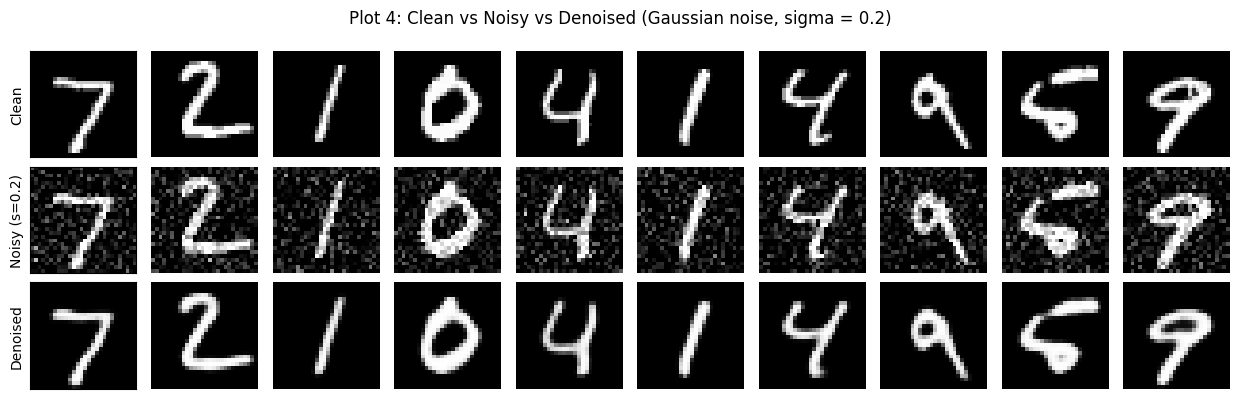

In [15]:
# Plot 4: clean vs noisy vs denoised for 10 test images at the training noise level
grid_plot([x_test, xn_test[TRAIN_SIGMA], dae_recon], ["Clean", f"Noisy (s={TRAIN_SIGMA})", "Denoised"],
          f"Plot 4: Clean vs Noisy vs Denoised (Gaussian noise, sigma = {TRAIN_SIGMA})",
          "plot4_clean_noisy_denoised", n=10)

Gaussian noise:
   Noise  Level       Stage     MSE     MAE    SSIM
Gaussian    0.1 Noisy input 0.00541 0.04396 0.67900
Gaussian    0.1    Denoised 0.00366 0.01770 0.96009
Gaussian    0.2 Noisy input 0.02114 0.08640 0.59411
Gaussian    0.2    Denoised 0.00459 0.02088 0.94549
Gaussian    0.3 Noisy input 0.04648 0.12772 0.50993
Gaussian    0.3    Denoised 0.00696 0.02887 0.87093

Salt-and-pepper noise (model trained only on Gaussian):
          Noise  Level       Stage     MSE     MAE    SSIM
Salt-and-pepper   0.05 Noisy input 0.02416 0.02508 0.70854
Salt-and-pepper   0.05    Denoised 0.00472 0.02067 0.93048
Salt-and-pepper   0.10 Noisy input 0.04827 0.05012 0.57784
Salt-and-pepper   0.10    Denoised 0.00672 0.02640 0.87687
Salt-and-pepper   0.20 Noisy input 0.09652 0.10020 0.44577
Salt-and-pepper   0.20    Denoised 0.01287 0.04281 0.73986


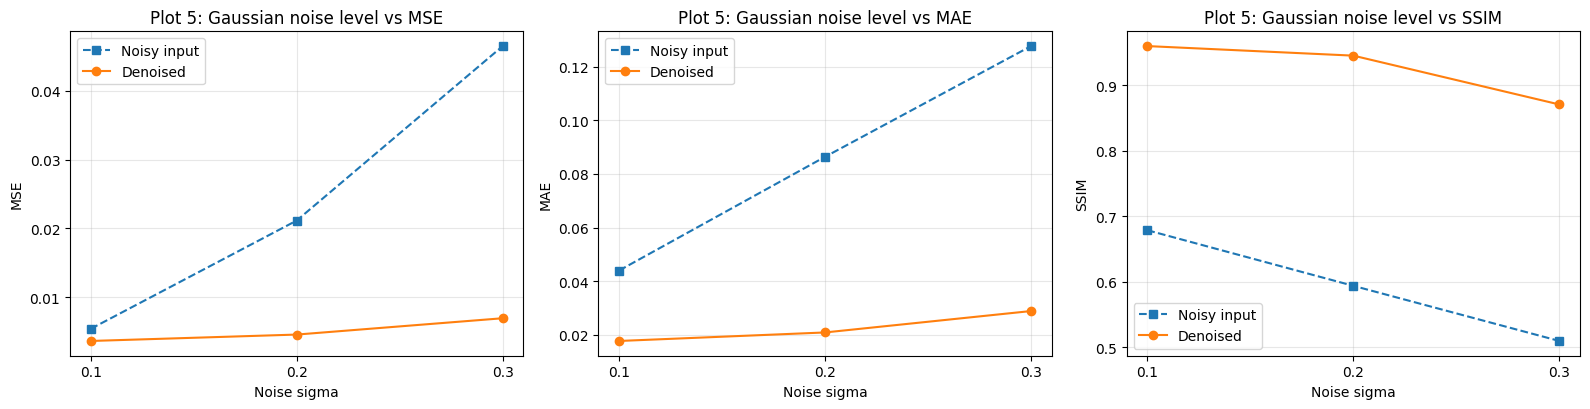

In [16]:
# Plot 5: reconstruction quality against noise level, with the raw noisy image as the do-nothing baseline
rows = []
for s in GAUSS_LEVELS:
    noisy = xn_test[s]
    rows.append({"Noise": "Gaussian", "Level": s, "Stage": "Noisy input", **image_metrics(x_test, noisy)})
    rows.append({"Noise": "Gaussian", "Level": s, "Stage": "Denoised", **image_metrics(x_test, dae.predict(noisy, verbose=0))})
for p in SP_LEVELS:
    noisy = xsp_test[p]
    rows.append({"Noise": "Salt-and-pepper", "Level": p, "Stage": "Noisy input", **image_metrics(x_test, noisy)})
    rows.append({"Noise": "Salt-and-pepper", "Level": p, "Stage": "Denoised", **image_metrics(x_test, dae.predict(noisy, verbose=0))})
noise_df = pd.DataFrame(rows)
print("Gaussian noise:"); print(noise_df[noise_df.Noise == "Gaussian"].round(5).to_string(index=False))
print("\nSalt-and-pepper noise (model trained only on Gaussian):")
print(noise_df[noise_df.Noise == "Salt-and-pepper"].round(5).to_string(index=False))

g = noise_df[noise_df.Noise == "Gaussian"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for a, metric in zip(ax, ["MSE", "MAE", "SSIM"]):
    for stage, style in [("Noisy input", "s--"), ("Denoised", "o-")]:
        d = g[g.Stage == stage]
        a.plot(d.Level, d[metric], style, label=stage)
    a.set(title=f"Plot 5: Gaussian noise level vs {metric}", xlabel="Noise sigma", ylabel=metric, xticks=GAUSS_LEVELS)
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); save_fig("plot5_noise_level_vs_quality"); plt.show()

In [17]:
# Variational autoencoder: sampling layer implementing the reparameterization trick and a model with an explicit ELBO train step
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps

def build_vae_parts(latent_dim=2):
    set_seed()
    enc_in = keras.Input((28, 28, 1))
    h = layers.Conv2D(32, 3, strides=2, activation="relu", padding="same")(enc_in)
    h = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(h)
    h = layers.Flatten()(h)
    h = layers.Dense(16, activation="relu")(h)
    mu = layers.Dense(latent_dim, name="mu")(h)
    logvar = layers.Dense(latent_dim, name="log_var")(h)
    z = Sampling()([mu, logvar])
    encoder = keras.Model(enc_in, [mu, logvar, z], name="encoder")

    dec_in = keras.Input((latent_dim,))
    d = layers.Dense(7 * 7 * 64, activation="relu")(dec_in)
    d = layers.Reshape((7, 7, 64))(d)
    d = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(d)
    d = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(d)
    dec_out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(d)
    decoder = keras.Model(dec_in, dec_out, name="decoder")
    return encoder, decoder

class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kw):
        super().__init__(**kw)
        self.encoder, self.decoder, self.beta = encoder, decoder, beta
        self.t_total = keras.metrics.Mean(name="loss")
        self.t_rec = keras.metrics.Mean(name="rec_loss")
        self.t_kl = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.t_total, self.t_rec, self.t_kl]

    def call(self, x):
        mu, logvar, z = self.encoder(x)
        return self.decoder(z)

    def compute_losses(self, x):
        mu, logvar, z = self.encoder(x)
        xhat = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, xhat), axis=(1, 2)))
        kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
        return rec, kl, rec + self.beta * kl

    def _update(self, rec, kl, total):
        self.t_total.update_state(total); self.t_rec.update_state(rec); self.t_kl.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            rec, kl, total = self.compute_losses(x)
        self.optimizer.apply_gradients(zip(tape.gradient(total, self.trainable_weights), self.trainable_weights))
        return self._update(rec, kl, total)

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        return self._update(*self.compute_losses(x))

encoder2, decoder2 = build_vae_parts(2)
encoder2.summary(); decoder2.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the 2-dimensional VAE with the ELBO objective (binary cross-entropy reconstruction term + KL to a standard normal prior)
VAE_EPOCHS = 30
set_seed()
vae = VAE(*build_vae_parts(2), beta=1.0)
vae.compile(optimizer=keras.optimizers.Adam(LR))
t0 = time.time()
vae_hist = vae.fit(x_train, x_train, validation_data=(x_val, x_val),
                   epochs=VAE_EPOCHS, batch_size=BATCH, verbose=2).history
vae_time = time.time() - t0

mu_test, logvar_test, _ = vae.encoder.predict(x_test, verbose=0)
vae_recon = vae.decoder.predict(mu_test, verbose=0)
vae_metrics = image_metrics(x_test, vae_recon)
results["VAE (latent 2)"] = {**vae_metrics, "Parameters": n_trainable(vae), "Time (s)": vae_time}
rec_te, kl_te, tot_te = [float(v) for v in vae.compute_losses(tf.constant(x_test))]
print(f"\nVAE test losses -> reconstruction {rec_te:.3f} | KL {kl_te:.3f} | total {tot_te:.3f}")
print("VAE test image metrics (decoded from mu):", {k: round(v, 5) for k, v in vae_metrics.items()})
print(f"Latent statistics: mean(mu) {mu_test.mean():.3f}, std(mu) {mu_test.std():.3f}, "
      f"mean(sigma) {np.exp(0.5*logvar_test).mean():.3f}")

Epoch 1/30
79/79 - 13s - 161ms/step - kl_loss: 2.3722 - loss: 297.0364 - rec_loss: 294.6641 - val_kl_loss: 1.9475 - val_loss: 213.4764 - val_rec_loss: 211.5288
Epoch 2/30
79/79 - 1s - 9ms/step - kl_loss: 2.4444 - loss: 208.4150 - rec_loss: 205.9706 - val_kl_loss: 3.1743 - val_loss: 202.4580 - val_rec_loss: 199.2837
Epoch 3/30
79/79 - 1s - 9ms/step - kl_loss: 3.1261 - loss: 200.4730 - rec_loss: 197.3468 - val_kl_loss: 3.5484 - val_loss: 197.7689 - val_rec_loss: 194.2205
Epoch 4/30
79/79 - 1s - 9ms/step - kl_loss: 3.3200 - loss: 197.3734 - rec_loss: 194.0533 - val_kl_loss: 3.6309 - val_loss: 195.2834 - val_rec_loss: 191.6524
Epoch 5/30
79/79 - 1s - 9ms/step - kl_loss: 3.3597 - loss: 195.6019 - rec_loss: 192.2421 - val_kl_loss: 3.5894 - val_loss: 194.1035 - val_rec_loss: 190.5141
Epoch 6/30
79/79 - 1s - 9ms/step - kl_loss: 3.3224 - loss: 194.2565 - rec_loss: 190.9341 - val_kl_loss: 3.3395 - val_loss: 192.7166 - val_rec_loss: 189.3772
Epoch 7/30
79/79 - 1s - 9ms/step - kl_loss: 3.2990 - lo

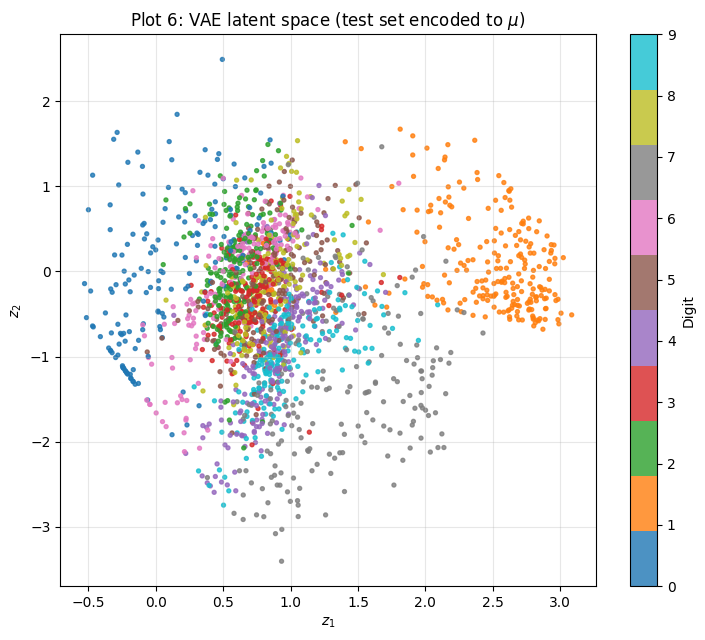

Per-digit latent centroid and spread:
      z1     z2  mean radius
0  0.122  0.045        0.814
1  2.432  0.083        0.622
2  0.608 -0.018        0.490
3  0.739 -0.329        0.400
4  0.903 -0.922        0.634
5  0.845 -0.152        0.542
6  0.600 -0.088        0.659
7  1.334 -1.354        0.877
8  0.854 -0.130        0.515
9  0.983 -0.966        0.525


In [19]:
# Plot 6: the two-dimensional VAE latent space, coloured by digit label (labels used for visualisation only)
plt.figure(figsize=(7.5, 6.5))
sc = plt.scatter(mu_test[:, 0], mu_test[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.8)
plt.colorbar(sc, ticks=range(10), label="Digit")
plt.xlabel("$z_1$"); plt.ylabel("$z_2$")
plt.title("Plot 6: VAE latent space (test set encoded to $\\mu$)")
plt.grid(alpha=0.3)
plt.tight_layout(); save_fig("plot6_vae_latent_space"); plt.show()

centroids = pd.DataFrame({d: mu_test[y_test == d].mean(0) for d in range(10)}, index=["z1", "z2"]).T
spread = pd.Series({d: float(np.mean(np.linalg.norm(mu_test[y_test == d] - mu_test[y_test == d].mean(0), axis=1))) for d in range(10)}, name="mean radius")
print("Per-digit latent centroid and spread:")
print(pd.concat([centroids, spread], axis=1).round(3))

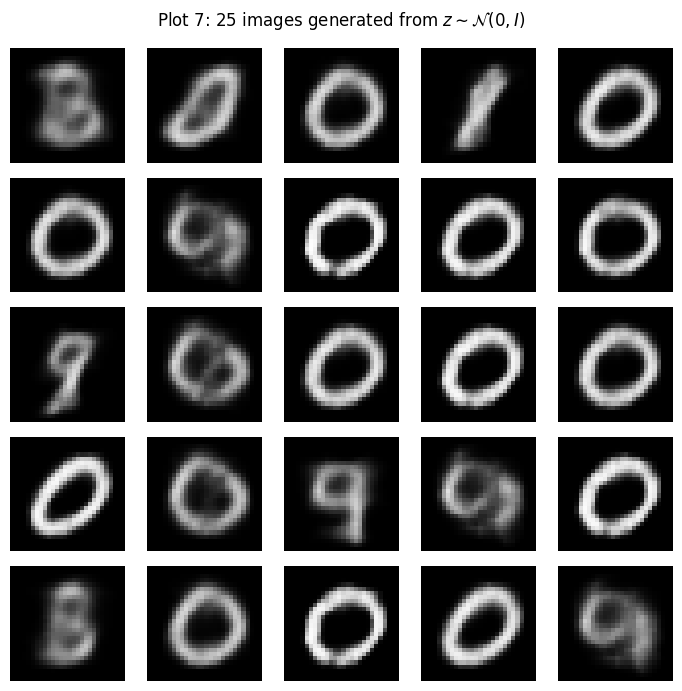

Mean pixel intensity of generated samples: 0.1682 | of real test images: 0.1209


In [20]:
# Plot 7: 25 new images decoded from latent vectors sampled straight from the N(0, I) prior
set_seed()
z_samples = np.random.RandomState(SEED).normal(size=(25, 2)).astype("float32")
generated = vae.decoder.predict(z_samples, verbose=0)
fig, axes = plt.subplots(5, 5, figsize=(7, 7))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(generated[i].squeeze(), cmap="gray", vmin=0, vmax=1); ax.axis("off")
fig.suptitle("Plot 7: 25 images generated from $z \\sim \\mathcal{N}(0, I)$")
plt.tight_layout(); save_fig("plot7_vae_generated"); plt.show()
print("Mean pixel intensity of generated samples:", round(float(generated.mean()), 4),
      "| of real test images:", round(float(x_test.mean()), 4))

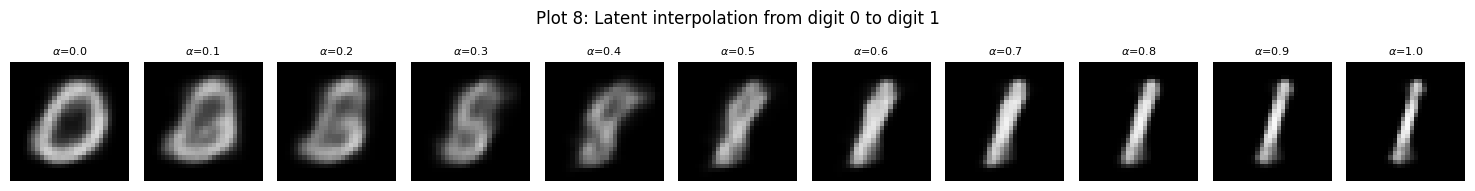

Pixel-space MSE between consecutive interpolation steps: [0.0118, 0.00684, 0.00907, 0.00671, 0.00568, 0.00453, 0.00287, 0.00294, 0.00156, 0.00089]
max/min step ratio = 13.24  (a ratio near 1 means a smooth, evenly paced path)


In [21]:
# Plot 8: latent-space interpolation between two encoded test digits, alpha from 0 to 1 in steps of 0.1
i_a = int(np.where(y_test == 0)[0][0])
i_b = int(np.where(y_test == 1)[0][0])
zA, zB = mu_test[i_a], mu_test[i_b]
alphas = np.linspace(0, 1, 11)
z_interp = np.stack([(1 - a) * zA + a * zB for a in alphas]).astype("float32")
interp_imgs = vae.decoder.predict(z_interp, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(1.35 * len(alphas), 2.0))
for ax, a, img in zip(axes, alphas, interp_imgs):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); ax.set_title(f"$\\alpha$={a:.1f}", fontsize=8); ax.axis("off")
fig.suptitle(f"Plot 8: Latent interpolation from digit {y_test[i_a]} to digit {y_test[i_b]}")
plt.tight_layout(); save_fig("plot8_latent_interpolation"); plt.show()

steps = np.array([float(np.mean((interp_imgs[i + 1] - interp_imgs[i]) ** 2)) for i in range(len(alphas) - 1)])
print("Pixel-space MSE between consecutive interpolation steps:", np.round(steps, 5).tolist())
print(f"max/min step ratio = {steps.max()/steps.min():.2f}  (a ratio near 1 means a smooth, evenly paced path)")

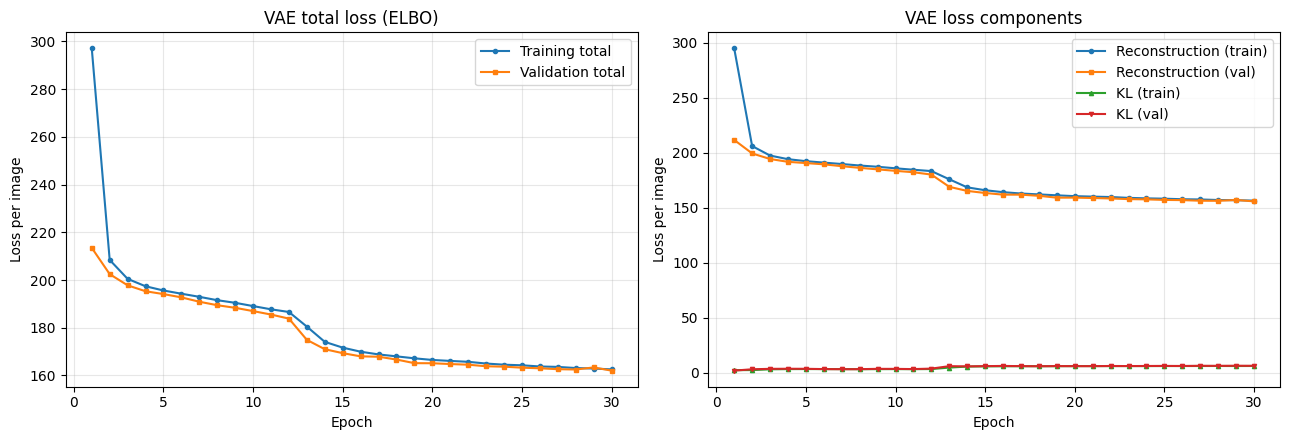

                         Value
Reconstruction Loss  155.17885
KL Loss                6.13317
Total Loss           161.31203
Test MSE               0.04611
Test MAE               0.10778
Mean SSIM              0.44859


In [22]:
# Plot 9 (VAE curves): total, reconstruction and KL loss per epoch, plus the VAE results table required in Section 21
ep = np.arange(1, len(vae_hist["loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, vae_hist["loss"], "o-", ms=3, label="Training total")
ax[0].plot(ep, vae_hist["val_loss"], "s-", ms=3, label="Validation total")
ax[0].set(title="VAE total loss (ELBO)", xlabel="Epoch", ylabel="Loss per image")
ax[1].plot(ep, vae_hist["rec_loss"], "o-", ms=3, label="Reconstruction (train)")
ax[1].plot(ep, vae_hist["val_rec_loss"], "s-", ms=3, label="Reconstruction (val)")
ax[1].plot(ep, vae_hist["kl_loss"], "^-", ms=3, label="KL (train)")
ax[1].plot(ep, vae_hist["val_kl_loss"], "v-", ms=3, label="KL (val)")
ax[1].set(title="VAE loss components", xlabel="Epoch", ylabel="Loss per image")
for a in ax:
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); save_fig("plot_vae_loss_curves"); plt.show()

vae_table = pd.DataFrame({"Value": {"Reconstruction Loss": rec_te, "KL Loss": kl_te, "Total Loss": tot_te,
                                    "Test MSE": vae_metrics["MSE"], "Test MAE": vae_metrics["MAE"],
                                    "Mean SSIM": vae_metrics["SSIM"]}})
print(vae_table.round(5))

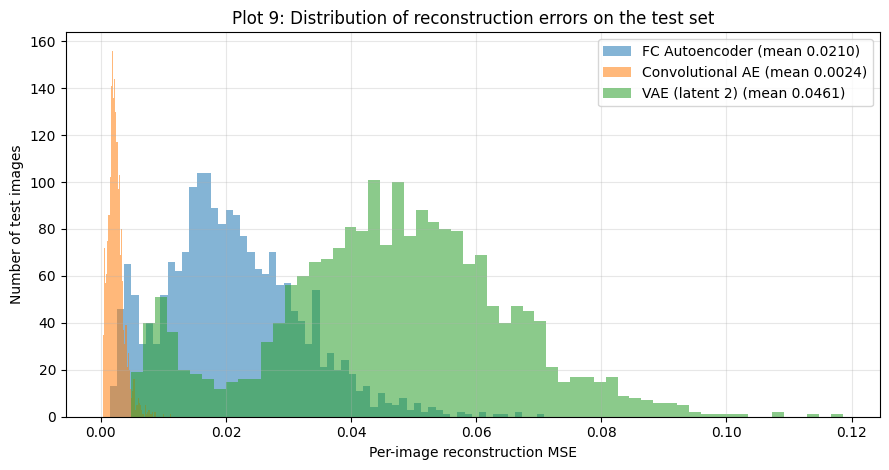

                     mean   median      p90      max     skew
FC Autoencoder    0.02100  0.01987  0.03491  0.07086  0.65221
Convolutional AE  0.00241  0.00222  0.00397  0.01117  1.46465
VAE (latent 2)    0.04611  0.04690  0.06916  0.11862 -0.04016


In [23]:
# Plot 9: distribution of per-image reconstruction error on the test set for the three deterministic models
errs = {"FC Autoencoder": per_image_mse(xf_test, fc_recon),
        "Convolutional AE": per_image_mse(x_test, cae_recon),
        "VAE (latent 2)": per_image_mse(x_test, vae_recon)}
plt.figure(figsize=(9, 4.8))
for name, e in errs.items():
    plt.hist(e, bins=60, alpha=0.55, label=f"{name} (mean {e.mean():.4f})")
plt.xlabel("Per-image reconstruction MSE"); plt.ylabel("Number of test images")
plt.title("Plot 9: Distribution of reconstruction errors on the test set")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); save_fig("plot9_error_distribution"); plt.show()

summary = pd.DataFrame({name: {"mean": e.mean(), "median": np.median(e), "p90": np.percentile(e, 90),
                               "max": e.max(), "skew": float(pd.Series(e).skew())} for name, e in errs.items()}).T
print(summary.round(5))

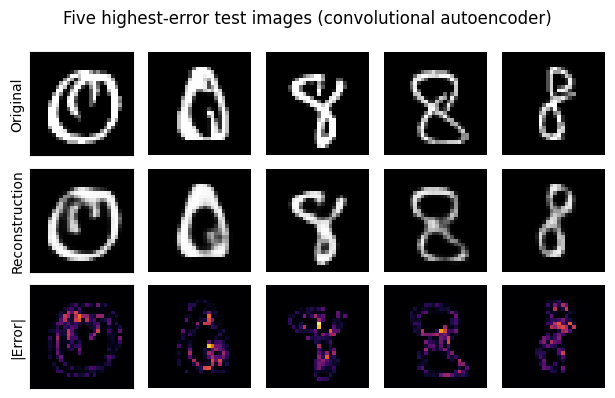

 Sample  Test index  True digit  Per-image MSE  Ink fraction
      1        1526           0        0.01117        0.2002
      2         895           0        0.01004        0.1736
      3        1125           8        0.00866        0.1259
      4         431           8        0.00865        0.1026
      5        1320           8        0.00859        0.0800

Mean ink fraction over the whole test set: 0.1209


In [24]:
# Five highest-error test images for the convolutional autoencoder, with their labels and errors
cae_err = errs["Convolutional AE"]
worst = np.argsort(cae_err)[-5:][::-1]
grid_plot([x_test[worst], cae_recon[worst], np.abs(as_images(x_test[worst]) - as_images(cae_recon[worst]))],
          ["Original", "Reconstruction", "|Error|"],
          "Five highest-error test images (convolutional autoencoder)",
          "plot_high_error_samples", n=5, cmaps=["gray", "gray", "inferno"])
print(pd.DataFrame({"Sample": range(1, 6), "Test index": worst, "True digit": y_test[worst],
                    "Per-image MSE": cae_err[worst].round(5),
                    "Ink fraction": as_images(x_test[worst]).mean(axis=(1, 2)).round(4)}).to_string(index=False))
print(f"\nMean ink fraction over the whole test set: {as_images(x_test).mean():.4f}")

In [25]:
# Consolidated results across all four models
cons = pd.DataFrame(results).T[["MSE", "MAE", "SSIM", "Parameters", "Time (s)"]]
print(cons.round(5))

                      MSE      MAE     SSIM  Parameters  Time (s)
FC Autoencoder    0.02100  0.05547  0.75181    211040.0  14.05259
Convolutional AE  0.00241  0.01464  0.97404     74497.0  23.13469
Denoising CAE     0.00459  0.02088  0.94549     74497.0  20.06137
VAE (latent 2)    0.04611  0.10778  0.44859    134165.0  33.91933


d_z= 2 | MSE 0.04716 | MAE 0.11076 | SSIM 0.4386 | params 210130
d_z= 8 | MSE 0.03040 | MAE 0.07533 | SSIM 0.6505 | params 210520
d_z=16 | MSE 0.02100 | MAE 0.05547 | SSIM 0.7518 | params 211040
d_z=32 | MSE 0.01997 | MAE 0.05420 | SSIM 0.7596 | params 212080

 Latent Dimension     MSE     MAE    SSIM  Parameters  Time (s)
                2 0.04716 0.11076 0.43855      210130  13.27817
                8 0.03040 0.07533 0.65050      210520  12.54674
               16 0.02100 0.05547 0.75181      211040  14.05259
               32 0.01997 0.05420 0.75964      212080  11.99107


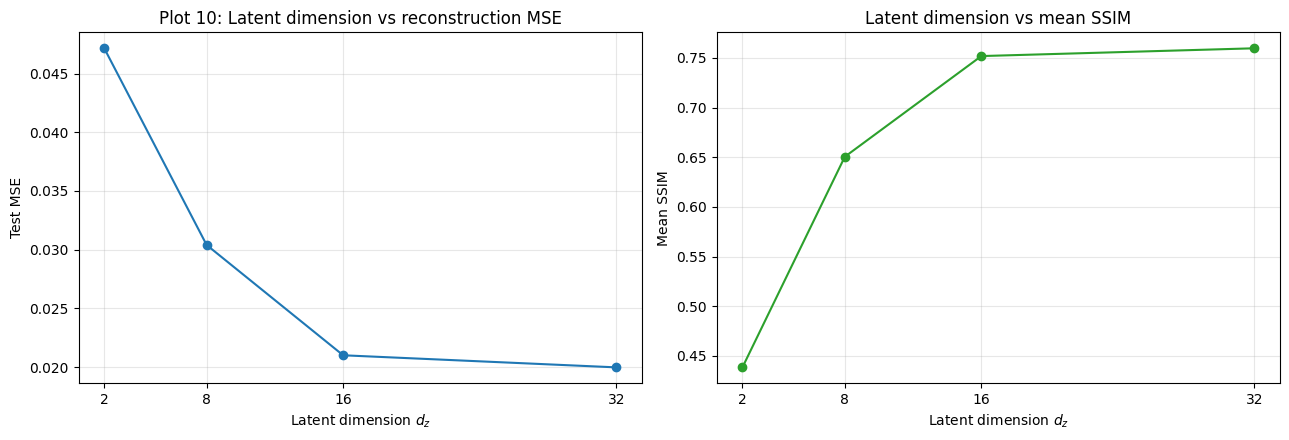

In [26]:
# Latent-dimension study on the basic autoencoder: d_z in {2, 8, 16, 32}, everything else unchanged (Plot 10)
LATENT_DIMS = [2, 8, 16, 32]
lat_rows = []
for dz in LATENT_DIMS:
    if dz == 16:
        m_metrics, params, secs = image_metrics(xf_test, fc_recon), n_trainable(fc_ae), fc_time
    else:
        m = build_fc_ae(dz)
        t0 = time.time()
        m.fit(xf_train, xf_train, validation_data=(xf_val, xf_val), epochs=EPOCHS, batch_size=BATCH, verbose=0)
        secs = time.time() - t0
        m_metrics, params = image_metrics(xf_test, m.predict(xf_test, verbose=0)), n_trainable(m)
    lat_rows.append({"Latent Dimension": dz, **m_metrics, "Parameters": params, "Time (s)": secs})
    print(f"d_z={dz:>2} | MSE {m_metrics['MSE']:.5f} | MAE {m_metrics['MAE']:.5f} | SSIM {m_metrics['SSIM']:.4f} | params {params}")
lat_df = pd.DataFrame(lat_rows)
print()
print(lat_df.round(5).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(lat_df["Latent Dimension"], lat_df["MSE"], "o-")
ax[0].set(title="Plot 10: Latent dimension vs reconstruction MSE", xlabel="Latent dimension $d_z$", ylabel="Test MSE", xticks=LATENT_DIMS)
ax[1].plot(lat_df["Latent Dimension"], lat_df["SSIM"], "o-", color="tab:green")
ax[1].set(title="Latent dimension vs mean SSIM", xlabel="Latent dimension $d_z$", ylabel="Mean SSIM", xticks=LATENT_DIMS)
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); save_fig("plot10_latent_dimension"); plt.show()

In [27]:
# Additional exercise 1: convolutional autoencoder with an explicit dense bottleneck of 4, 8, 16 and 32 units
def build_cae_bottleneck(dz):
    set_seed()
    inp = keras.Input((28, 28, 1))
    e = layers.Conv2D(32, 3, strides=2, activation="relu", padding="same")(inp)
    e = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(e)
    e = layers.Flatten()(e)
    z = layers.Dense(dz, activation="relu", name="latent")(e)
    d = layers.Dense(7 * 7 * 64, activation="relu")(z)
    d = layers.Reshape((7, 7, 64))(d)
    d = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(d)
    d = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(d)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(d)
    m = keras.Model(inp, out, name=f"cae_bottleneck{dz}")
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="binary_crossentropy")
    return m

ex1_rows = []
for dz in [4, 8, 16, 32]:
    m = build_cae_bottleneck(dz)
    t0 = time.time()
    m.fit(x_train, x_train, validation_data=(x_val, x_val), epochs=EPOCHS, batch_size=BATCH, verbose=0)
    secs = time.time() - t0
    mm = image_metrics(x_test, m.predict(x_test, verbose=0))
    ex1_rows.append({"Latent Dimension": dz, **mm, "Parameters": n_trainable(m), "Time (s)": secs})
    print(f"CAE bottleneck d_z={dz:>2} | MSE {mm['MSE']:.5f} | SSIM {mm['SSIM']:.4f} | params {n_trainable(m)}")
ex1_df = pd.DataFrame(ex1_rows)
print()
print(ex1_df.round(5).to_string(index=False))

CAE bottleneck d_z= 4 | MSE 0.03491 | SSIM 0.6291 | params 102725
CAE bottleneck d_z= 8 | MSE 0.02126 | SSIM 0.7621 | params 127817
CAE bottleneck d_z=16 | MSE 0.01327 | SSIM 0.8531 | params 178001
CAE bottleneck d_z=32 | MSE 0.00681 | SSIM 0.9254 | params 278369

 Latent Dimension     MSE     MAE    SSIM  Parameters  Time (s)
                4 0.03491 0.08328 0.62910      102725  21.24303
                8 0.02126 0.05525 0.76205      127817  21.29847
               16 0.01327 0.03923 0.85307      178001  21.18449
               32 0.00681 0.02534 0.92537      278369  22.06192


Tested on               Gaussian 0.1  Gaussian 0.2  Gaussian 0.3  S&P 0.10  \
Trained on                                                                   
Gaussian sigma=0.1            0.9655        0.8705        0.6784    0.7695   
Gaussian sigma=0.2            0.9601        0.9455        0.8709    0.8769   
Salt-and-pepper p=0.10        0.8257        0.6523        0.5753    0.9461   

Tested on               S&P 0.20  
Trained on                        
Gaussian sigma=0.1        0.6379  
Gaussian sigma=0.2        0.7399  
Salt-and-pepper p=0.10    0.8951  

Tested on               Gaussian 0.1  Gaussian 0.2  Gaussian 0.3  S&P 0.10  \
Trained on                                                                   
Gaussian sigma=0.1           0.00303       0.00509       0.01058   0.00856   
Gaussian sigma=0.2           0.00366       0.00459       0.00696   0.00672   
Salt-and-pepper p=0.10       0.00898       0.01592       0.02413   0.00478   

Tested on               S&P 0.20  
Trained

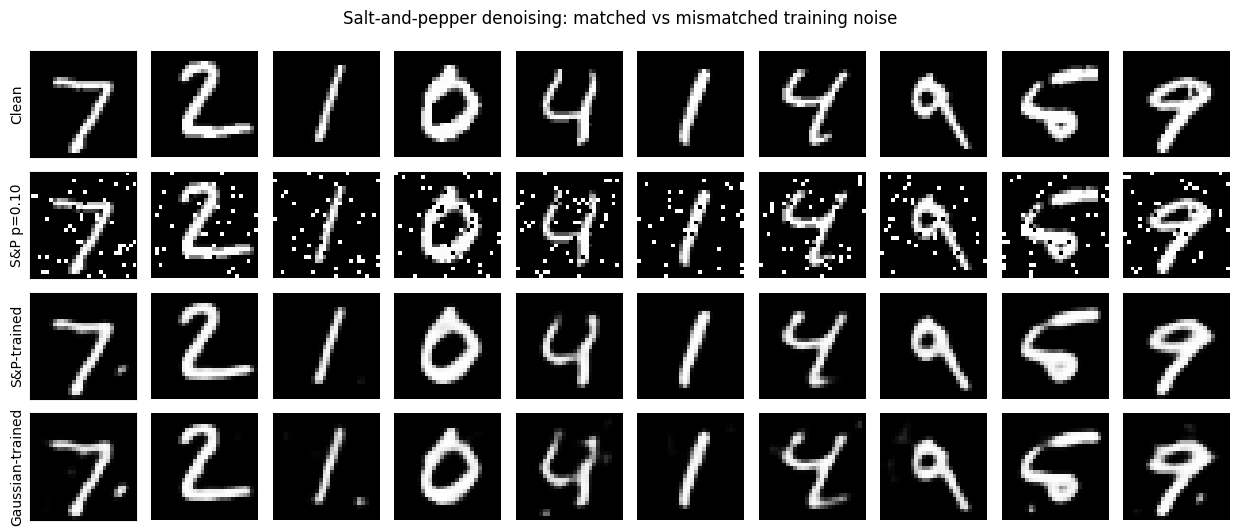

In [28]:
# Additional exercises 2 and 3: a salt-and-pepper-trained denoiser and a low-noise-trained denoiser, evaluated against the sigma=0.2 model
xsp_train = add_salt_pepper(x_train, 0.10, seed=5)
xsp_val = add_salt_pepper(x_val, 0.10, seed=6)
xlow_train, xlow_val = add_gaussian(x_train, 0.1, seed=7), add_gaussian(x_val, 0.1, seed=8)

dae_sp = build_cae()
dae_sp.fit(xsp_train, x_train, validation_data=(xsp_val, x_val), epochs=EPOCHS, batch_size=BATCH, verbose=0)
dae_low = build_cae()
dae_low.fit(xlow_train, x_train, validation_data=(xlow_val, x_val), epochs=EPOCHS, batch_size=BATCH, verbose=0)

ex23 = []
for train_name, model in [("Gaussian sigma=0.2", dae), ("Gaussian sigma=0.1", dae_low), ("Salt-and-pepper p=0.10", dae_sp)]:
    for test_name, noisy in [("Gaussian 0.1", xn_test[0.1]), ("Gaussian 0.2", xn_test[0.2]),
                             ("Gaussian 0.3", xn_test[0.3]), ("S&P 0.10", xsp_test[0.10]), ("S&P 0.20", xsp_test[0.20])]:
        mm = image_metrics(x_test, model.predict(noisy, verbose=0))
        ex23.append({"Trained on": train_name, "Tested on": test_name, **mm})
ex23_df = pd.DataFrame(ex23)
print(ex23_df.pivot(index="Trained on", columns="Tested on", values="SSIM").round(4))
print()
print(ex23_df.pivot(index="Trained on", columns="Tested on", values="MSE").round(5))

grid_plot([x_test, xsp_test[0.10], dae_sp.predict(xsp_test[0.10], verbose=0), dae.predict(xsp_test[0.10], verbose=0)],
          ["Clean", "S&P p=0.10", "S&P-trained", "Gaussian-trained"],
          "Salt-and-pepper denoising: matched vs mismatched training noise",
          "plot_extra_salt_pepper", n=10)

                             MSE      MAE     SSIM  Parameters  Time (s)
UpSampling2D decoder     0.00241  0.01464  0.97404     74497.0  23.13469
Conv2DTranspose decoder  0.00219  0.01378  0.97718    111425.0  23.56569


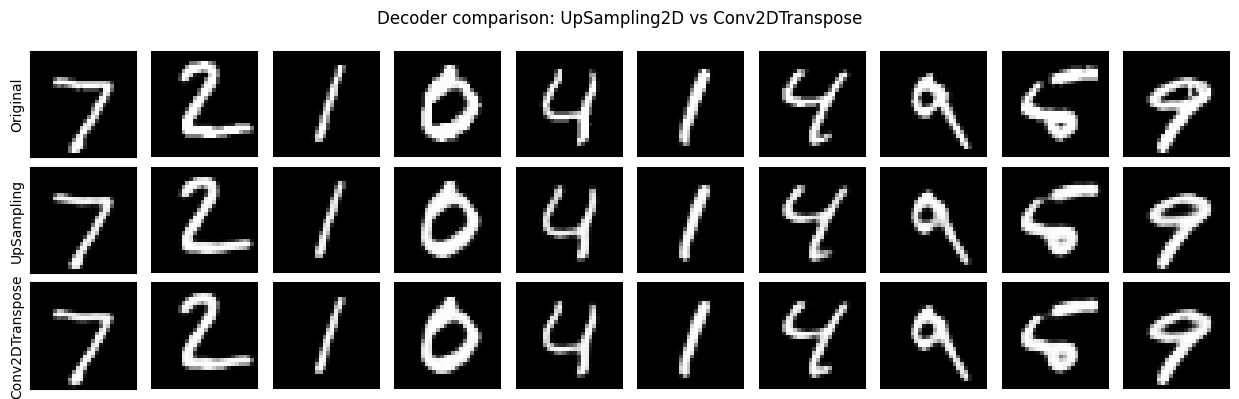

In [29]:
# Additional exercise 4: transposed-convolution decoder versus the UpSampling2D decoder
cae_t = build_cae(transpose_decoder=True)
t0 = time.time()
cae_t.fit(x_train, x_train, validation_data=(x_val, x_val), epochs=EPOCHS, batch_size=BATCH, verbose=0)
cae_t_time = time.time() - t0
cae_t_recon = cae_t.predict(x_test, verbose=0)
ex4 = pd.DataFrame({"UpSampling2D decoder": {**image_metrics(x_test, cae_recon), "Parameters": n_trainable(cae), "Time (s)": cae_time},
                    "Conv2DTranspose decoder": {**image_metrics(x_test, cae_t_recon), "Parameters": n_trainable(cae_t), "Time (s)": cae_t_time}}).T
print(ex4.round(5))
grid_plot([x_test, cae_recon, cae_t_recon], ["Original", "UpSampling", "Conv2DTranspose"],
          "Decoder comparison: UpSampling2D vs Conv2DTranspose",
          "plot_extra_decoder_comparison", n=10)

In [30]:
# Additional exercises 5 and 6: an 8-dimensional VAE and two KL weightings (beta = 0.5 and beta = 4)
def train_vae(latent_dim, beta, epochs=VAE_EPOCHS):
    set_seed()
    m = VAE(*build_vae_parts(latent_dim), beta=beta)
    m.compile(optimizer=keras.optimizers.Adam(LR))
    t0 = time.time()
    h = m.fit(x_train, x_train, validation_data=(x_val, x_val), epochs=epochs, batch_size=BATCH, verbose=0).history
    secs = time.time() - t0
    mu, logvar, _ = m.encoder.predict(x_test, verbose=0)
    rec, kl, tot = [float(v) for v in m.compute_losses(tf.constant(x_test))]
    mm = image_metrics(x_test, m.decoder.predict(mu, verbose=0))
    return m, {"latent": latent_dim, "beta": beta, **mm, "Rec loss": rec, "KL loss": kl,
               "Total loss": tot, "Active dims": int((mu.std(0) > 0.1).sum()), "Time (s)": secs}, h

vae_rows = [{"latent": 2, "beta": 1.0, **vae_metrics, "Rec loss": rec_te, "KL loss": kl_te,
             "Total loss": tot_te, "Active dims": int((mu_test.std(0) > 0.1).sum()), "Time (s)": vae_time}]
vae8, r8, _ = train_vae(8, 1.0)
vae_rows.append(r8)
for b in [0.5, 4.0]:
    _, rb, _ = train_vae(2, b)
    vae_rows.append(rb)
vae_df = pd.DataFrame(vae_rows)
print(vae_df.round(4).to_string(index=False))

 latent  beta    MSE    MAE   SSIM  Rec loss  KL loss  Total loss  Active dims  Time (s)
      2   1.0 0.0461 0.1078 0.4486  155.1788   6.1332    161.3120            2   33.9193
      8   1.0 0.0466 0.1100 0.4458  158.5507   6.2335    164.7842            4   33.6724
      2   0.5 0.0448 0.1029 0.4762  152.1612   7.1272    155.7248            2   31.8336
      2   4.0 0.0460 0.1089 0.4414  157.6099   3.4467    171.3966            2   32.0902


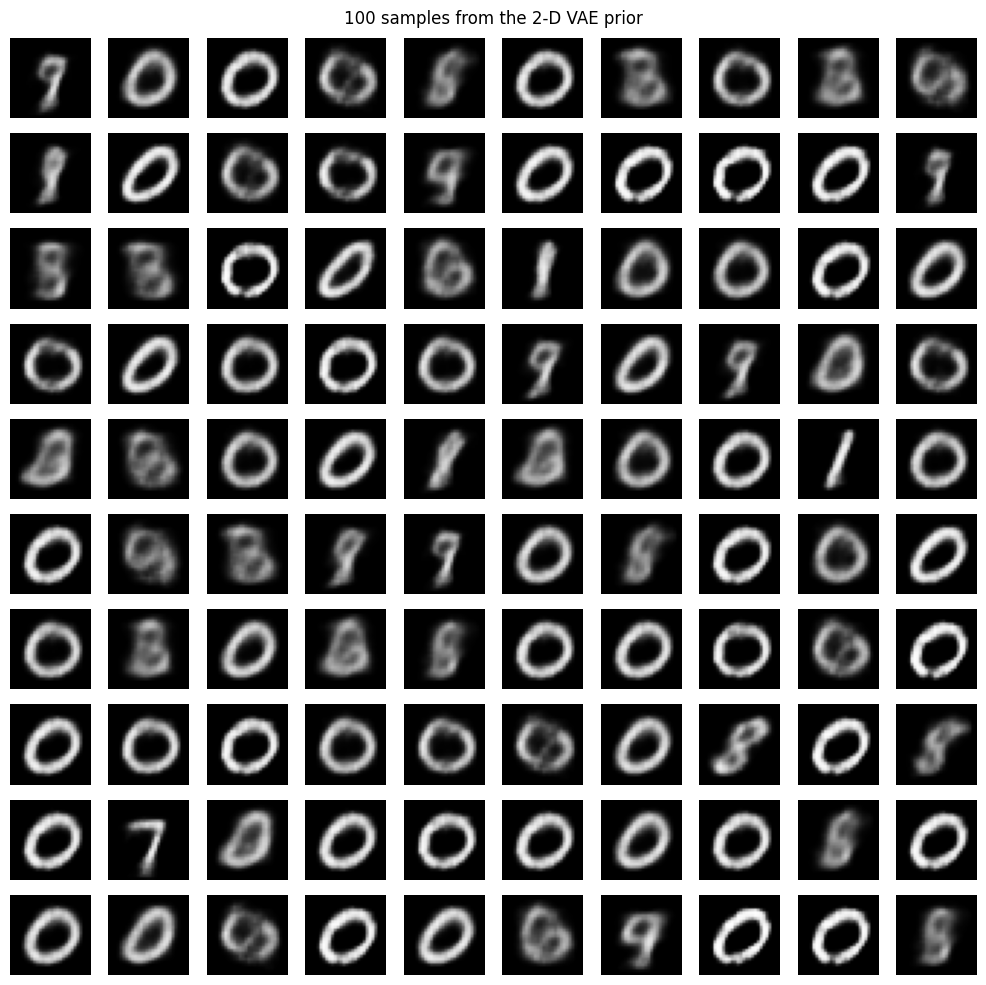

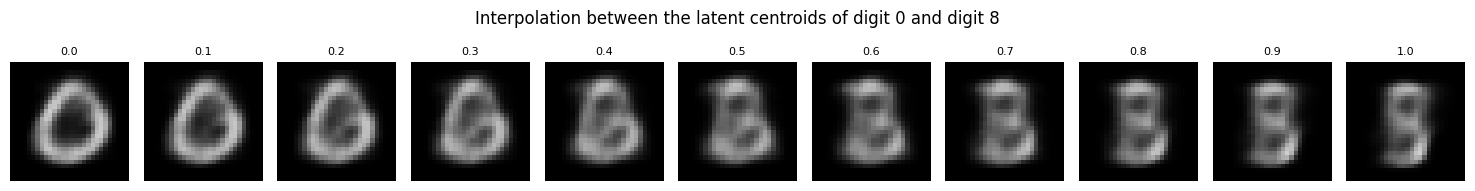

Centroid of digit 0: [0.122 0.045] | centroid of digit 8: [ 0.854 -0.13 ]


In [31]:
# Additional exercises 7 and 8: a 100-sample generation grid and interpolation between two digit-class centroids
z_big = np.random.RandomState(7).normal(size=(100, 2)).astype("float32")
big = vae.decoder.predict(z_big, verbose=0)
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(big[i].squeeze(), cmap="gray", vmin=0, vmax=1); ax.axis("off")
fig.suptitle("100 samples from the 2-D VAE prior")
plt.tight_layout(); save_fig("plot_extra_generated_100"); plt.show()

zA_c = mu_test[y_test == 0].mean(0)
zB_c = mu_test[y_test == 8].mean(0)
z_path = np.stack([(1 - a) * zA_c + a * zB_c for a in alphas]).astype("float32")
path_imgs = vae.decoder.predict(z_path, verbose=0)
fig, axes = plt.subplots(1, len(alphas), figsize=(1.35 * len(alphas), 2.0))
for ax, a, img in zip(axes, alphas, path_imgs):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); ax.set_title(f"{a:.1f}", fontsize=8); ax.axis("off")
fig.suptitle("Interpolation between the latent centroids of digit 0 and digit 8")
plt.tight_layout(); save_fig("plot_extra_centroid_interpolation"); plt.show()
print("Centroid of digit 0:", zA_c.round(3), "| centroid of digit 8:", zB_c.round(3))

In [33]:
# Save every results table as CSV and bundle the figures for download
cons.to_csv(f"{WORK_DIR}/results_consolidated.csv")
noise_df.to_csv(f"{WORK_DIR}/results_noise_levels.csv", index=False)
lat_df.to_csv(f"{WORK_DIR}/results_latent_dimension.csv", index=False)
ex1_df.to_csv(f"{WORK_DIR}/results_cae_bottleneck.csv", index=False)
ex23_df.to_csv(f"{WORK_DIR}/results_denoise_transfer.csv", index=False)
ex4.to_csv(f"{WORK_DIR}/results_decoder_comparison.csv")
vae_df.to_csv(f"{WORK_DIR}/results_vae_variants.csv", index=False)
vae_table.to_csv(f"{WORK_DIR}/results_vae_losses.csv")
shutil.make_archive(f"{WORK_DIR}/exp7_figures", "zip", FIG_DIR)
print("Figures:", sorted(os.listdir(FIG_DIR)))
print("CSV files:", sorted(f for f in os.listdir(WORK_DIR) if f.startswith("results_")))

Figures: ['plot10_latent_dimension.jpg', 'plot1_fc_reconstruction.jpg', 'plot2_fc_loss_curves.jpg', 'plot3_fc_vs_cae.jpg', 'plot4_clean_noisy_denoised.jpg', 'plot5_noise_level_vs_quality.jpg', 'plot6_vae_latent_space.jpg', 'plot7_vae_generated.jpg', 'plot8_latent_interpolation.jpg', 'plot9_error_distribution.jpg', 'plot_extra_centroid_interpolation.jpg', 'plot_extra_decoder_comparison.jpg', 'plot_extra_generated_100.jpg', 'plot_extra_salt_pepper.jpg', 'plot_high_error_samples.jpg', 'plot_vae_loss_curves.jpg']
CSV files: ['results_cae_bottleneck.csv', 'results_consolidated.csv', 'results_decoder_comparison.csv', 'results_denoise_transfer.csv', 'results_latent_dimension.csv', 'results_noise_levels.csv', 'results_vae_losses.csv', 'results_vae_variants.csv']
